# 코골이 검출 파이프라인 한눈에 보기

이 노트북의 목적은 **'전처리'라는 한 단어에 섞여 있던 두 작업을 분리**해서, 데이터가 어디서 어디로 흐르는지 못박는 것이다.

세 가지를 실제 샘플(`../data/raw`)로 따라간다.
1. 파이프라인 **A(라벨 생성)** 와 **B(모델 입력 전처리)** 의 분리
2. `snore_extract.py`가 만든 **에피소드(≥5초)** 를 모델이 먹는 **고정 길이 클립(`CLIP_SEC`)** 으로 잇는 단계
3. 학습 == 추론에서 똑같이 쓰는 **단일 소스 함수**(`utils/clip_features.py`)

## 0. '전처리'는 사실 두 개다

```
[A] 라벨 생성 (오프라인, 1회성)            <- preprocessing/snore_extract.py
    긴 녹음(mp3/mp4/wav)
        | 1초 분석 프레임(FRAME_SEC)으로 에너지+저주파+주기성 검사
        v
    코골이 에피소드 (>=5초)  --+
                              |  다리: episode_to_clips -> 고정 길이 클립(CLIP_SEC)
[B] 모델 입력 전처리 (학습.추론 동일)       <- utils/clip_features.py
    CLIP_SEC 클립  <----------+
        | clip_to_logmel(DC offset+멜 dB) -> logmel_to_image(224x224)
        v
    CNN --> 코골이 확률
```

**핵심 규칙**
- '학습 전처리 == 추론 전처리' 동일성은 **B에만** 적용된다. A(snore_extract.py)는 추론 때 돌지 않는다.
- **두 '윈도우'는 다른 층이다**: A의 `FRAME_SEC`(1초)는 *검출 분석 프레임*, `CLIP_SEC`(기본 4초)는 *모델 입력 클립 길이*. 섞어서 보면 안 된다.
- **클립 길이는 자유로운 하이퍼파라미터**다. 예전 1초는 오픈소스 데이터셋이 1초였던 것뿐. 코골이의 '드르렁-쉼-드르렁' 리듬(호흡 주기 ~2-6초)을 한 창에 담도록 **다중초(기본 4초)** 로 둔다. 단 학습과 추론이 같은 `CLIP_SEC`을 써야 한다(멜을 224폭으로 리사이즈하므로 길이가 다르면 skew).

In [1]:
import os, sys
import numpy as np
import librosa, librosa.display
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans', 'sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False

# snore_extract 는 preprocessing/, clip_features 는 utils/ 에 있다.
ROOT = os.path.abspath('..')
for sub in ('preprocessing', 'utils'):
    p = os.path.join(ROOT, sub)
    if p not in sys.path:
        sys.path.append(p)

import snore_extract as se   # 규칙기반 검출 로직(A)
from clip_features import episode_to_clips, clip_to_logmel, logmel_to_image, CLIP_SEC, HOP_LENGTH

print('snore_extract  FRAME_SEC=%.1f(검출 프레임)  MIN_SEG_SEC=%.1f' % (se.FRAME_SEC, se.MIN_SEG_SEC))
print('clip_features  CLIP_SEC=%.1f(모델 클립 길이)' % CLIP_SEC)

snore_extract  FRAME_SEC=1.0(검출 프레임)  MIN_SEG_SEC=5.0
clip_features  CLIP_SEC=4.0(모델 클립 길이)


## 1. 실제 샘플 로드

파일: 20230904_SnoringSample_2.wav  |  길이 90.5초  |  sr 16000Hz


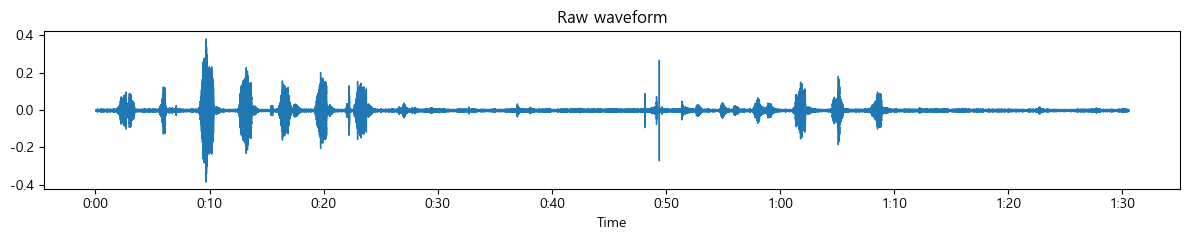

In [2]:
SAMPLE = os.path.join(ROOT, 'data', 'raw', '20230904_SnoringSample_2.wav')
y, sr = librosa.load(SAMPLE, sr=se.SR)
print('파일: %s  |  길이 %.1f초  |  sr %dHz' % (os.path.basename(SAMPLE), len(y)/sr, sr))

plt.figure(figsize=(12, 2.5))
librosa.display.waveshow(y, sr=sr)
plt.title('Raw waveform'); plt.tight_layout(); plt.show()

## 2. 파이프라인 A — snore_extract.py (라벨 생성)

`snore_extract.py`의 함수를 그대로 import 해서 코골이 **에피소드**를 검출한다. 출력은 `(시작초, 끝초)` 에피소드 = 학습용 양성 후보. (추론 때는 돌지 않음)

In [3]:
cfg = se.SENSITIVITY['high']
times, rms, lowband_ratio = se.frame_features(y, sr)   # 1초 분석 프레임 단위
mask = se.detect_frames(rms, lowband_ratio, cfg)
segs = se.group_segments(mask, times)

kept = []
for s in segs:
    if s[1] - s[0] < se.MIN_SEG_SEC:
        continue
    if not se.check_periodicity(s, mask, times):
        continue
    kept.append(s)

print('후보 %d개 -> 필터 후 %d개 에피소드' % (len(segs), len(kept)))
for i, (s, e) in enumerate(kept, 1):
    print('  에피소드 %d: %.1fs ~ %.1fs  (길이 %.1fs)' % (i, s, e, e - s))

후보 2개 -> 필터 후 2개 에피소드
  에피소드 1: 2.0s ~ 25.0s  (길이 23.0s)
  에피소드 2: 58.5s ~ 66.5s  (길이 8.0s)


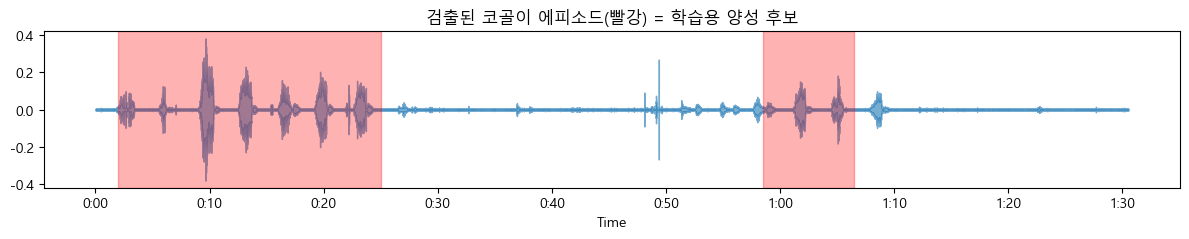

In [4]:
plt.figure(figsize=(12, 2.5))
librosa.display.waveshow(y, sr=sr, alpha=0.6)
for s, e in kept:
    plt.axvspan(s, e, color='red', alpha=0.3)
plt.title('검출된 코골이 에피소드(빨강) = 학습용 양성 후보')
plt.tight_layout(); plt.show()

## 3. 다리 — 에피소드를 고정 길이(CLIP_SEC) 클립으로

A의 에피소드는 5~24초로 길이가 제각각이다. 모델은 **고정 길이 클립**을 먹으므로 `episode_to_clips` 로 `CLIP_SEC`(기본 4초) 단위로 자른다.

- `CLIP_SEC`(4초)는 호흡 한 주기 이상을 담아 CNN이 코골이 리듬을 학습하게 한다. (1초가 아닌 이유)
- A의 검출 프레임(`FRAME_SEC`=1초)과는 **다른 값**이다 — 헷갈리지 말 것.

In [5]:
ep = kept[0]
clips = episode_to_clips(y, sr, ep)   # 기본 clip_sec=CLIP_SEC, hop=clip_sec
print('에피소드 %.1f~%.1fs (%.1fs) -> %.0f초 클립 %d개'
      % (ep[0], ep[1], ep[1]-ep[0], CLIP_SEC, len(clips)))

에피소드 2.0~25.0s (23.0s) -> 4초 클립 5개


## 4. 파이프라인 B — 클립 → 모델 입력 (학습 == 추론 동일)

여기가 '전처리 동일성'이 걸린 구간이다. 아래 두 함수를 **학습 이미지 생성기(build_training_images.py)와 추론(inference.py)이 그대로 공유**한다.

- `clip_to_logmel` : DC offset 제거 → 멜 → dB(ref=np.max). (RMS 정규화는 ref=np.max 때문에 no-op, reduce_noise는 1초 클립 degenerate라 제외)
- `logmel_to_image` : dB 멜 → 224x224x3 결정적 이미지(matplotlib/디스크 없음).

clip_to_logmel: (128, 251) | logmel_to_image: (224, 224, 3) uint8


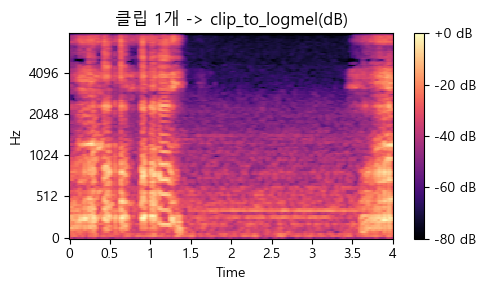

In [6]:
clip = clips[0]
mel_db = clip_to_logmel(clip, sr)
img = logmel_to_image(mel_db)
print('clip_to_logmel:', mel_db.shape, '| logmel_to_image:', img.shape, img.dtype)

plt.figure(figsize=(5, 3))
librosa.display.specshow(mel_db, sr=sr, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB'); plt.title('클립 1개 -> clip_to_logmel(dB)')
plt.tight_layout(); plt.show()

### 단일 소스로 해결됨

예전엔 디노이즈가 inference(reduce_noise) / snore_extract(없음) / EDA(stationary 등)로 3종 혼재였고, 멜→이미지도 matplotlib PNG 왕복이라 skew 위험이 컸다. 지금은:
- 전처리·멜·이미지가 모두 `utils/clip_features.py` 한 곳에 있고 학습/추론이 같은 함수를 import 한다.
- `logmel_to_image`는 결정적이라 PNG로 저장하든 바로 쓰든 픽셀이 동일하다.

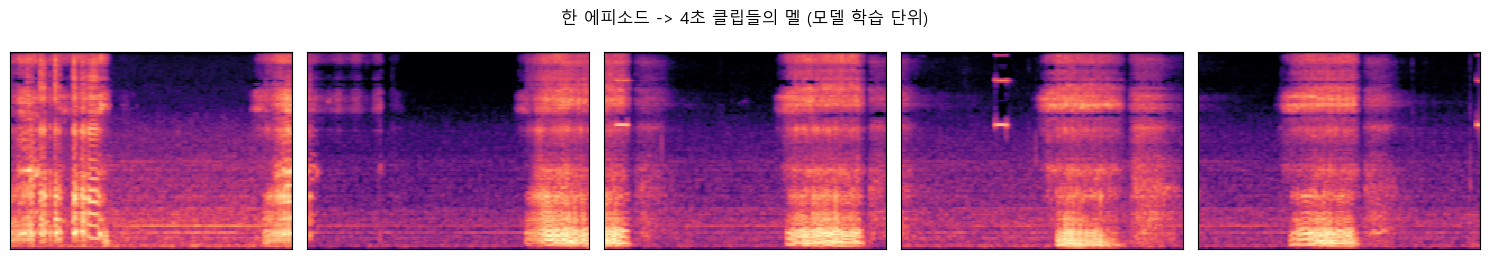

In [7]:
n = min(len(clips), 6)
fig, axes = plt.subplots(1, n, figsize=(3 * n, 2.6))
if n == 1:
    axes = [axes]
for ax, c in zip(axes, clips[:n]):
    librosa.display.specshow(clip_to_logmel(c, sr), sr=sr, hop_length=HOP_LENGTH, ax=ax)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('한 에피소드 -> %.0f초 클립들의 멜 (모델 학습 단위)' % CLIP_SEC)
plt.tight_layout(); plt.show()

## 5. 정리 — 머릿속에 박을 것

1. **A != B.** snore_extract.py(A)는 학습 데이터 채굴용, 추론 때 안 돈다. 동일성 원칙은 B(clip_features)에만.
2. **두 윈도우 구분.** A의 `FRAME_SEC`(1초)=검출 분석 프레임, `CLIP_SEC`(4초)=모델 입력 클립. 다른 층이다.
3. **단일 소스.** `episode_to_clips`·`clip_to_logmel`·`logmel_to_image`·`CLIP_SEC` 가 `utils/clip_features.py` 한 곳에 있고, 학습 생성기(`preprocessing/build_training_images.py`)와 추론(`inference/inference.py`)이 공유한다.
4. **클립 길이는 자유.** 1초는 오픈소스 데이터 유래일 뿐. `CLIP_SEC` 하나만 바꾸면 전체가 따라온다(학습==추론 동일 유지).

관련 문서: [EDA.md](EDA.md), [../preprocessing/snore_extract_explanation.md](../preprocessing/snore_extract_explanation.md)